<a href="https://colab.research.google.com/github/springboardmentor2468a-lab/AgriYield/blob/RAJASRI_J/AgriYield_Predictor(New).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
crop= pd.read_csv("Crop.csv")
fao= pd.read_csv("FAO(1).csv")

In [2]:
fao


,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code (CPC),Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
0,QCL,Crops and livestock products,356,India,5312,Area harvested,1654.0,"Anise, badian, coriander, cumin, caraway, fenn...",2001,2001,ha,5.692710e+05,A,Official figure,NaN
1,QCL,Crops and livestock products,356,India,5412,Yield,1654.0,"Anise, badian, coriander, cumin, caraway, fenn...",2001,2001,kg/ha,4.303000e+02,A,Official figure,NaN
2,QCL,Crops and livestock products,356,India,5510,Production,1654.0,"Anise, badian, coriander, cumin, caraway, fenn...",2001,2001,t,2.449430e+05,A,Official figure,NaN
3,QCL,Crops and livestock products,356,India,5312,Area harvested,1654.0,"Anise, badian, coriander, cumin, caraway, fenn...",2002,2002,ha,5.470280e+05,A,Official figure,NaN
4,QCL,Crops and livestock products,356,India,5412,Yield,1654.0,"Anise, badian, coriander, cumin, caraway, fenn...",2002,2002,kg/ha,2.968000e+02,A,Official figure,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5686,QCL,Crops and livestock products,356,India,5412,Yield,111.0,Wheat,2022,2022,kg/ha,3.537300e+03,A,Official figure,NaN
5687,QCL,Crops and livestock products,356,India,5510,Production,111.0,Wheat,2022,2022,t,1.077421e+08,A,Official figure,NaN
5688,QCL,Crops and livestock products,356,India,5312,Area harvested,111.0,Wheat,2023,2023,ha,3.140072e+07,A,Official figure,NaN
5689,QCL,Crops and livestock products,356,India,5412,Yield,111.0,Wheat,2023,2023,kg/ha,3.520700e+03,A,Official figure,NaN


In [3]:
crop

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
...,...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee


In [4]:
fao['Item'].unique()[:40]

array(['Anise, badian, coriander, cumin, caraway, fennel and juniper berries, raw',
       'Apples', 'Apricots', 'Areca nuts', 'Bananas', 'Barley',
       'Beans, dry', 'Cabbages', 'Cantaloupes and other melons',
       'Carrots and turnips', 'Cashew nuts, in shell', 'Cassava, fresh',
       'Castor oil seeds', 'Cauliflowers and broccoli', 'Cherries',
       'Chick peas, dry',
       'Chillies and peppers, dry (Capsicum spp., Pimenta spp.), raw',
       'Chillies and peppers, green (Capsicum spp. and Pimenta spp.)',
       'Cocoa beans', 'Coconuts, in shell', 'Coffee, green', 'Coir, raw',
       'Cucumbers and gherkins', 'Eggplants (aubergines)', 'Figs',
       'Ginger, raw', 'Grapes', 'Green garlic',
       'Groundnuts, excluding shelled', 'Jute, raw or retted',
       'Kenaf, and other textile bast fibres, raw or retted',
       'Lemons and limes', 'Lentils, dry', 'Lettuce and chicory',
       'Linseed', 'Maize (corn)', 'Mangoes, guavas and mangosteens',
       'Millet', 'Mushrooms a

In [5]:
for i in fao['Item'].unique():
    print(i)

Anise, badian, coriander, cumin, caraway, fennel and juniper berries, raw
Apples
Apricots
Areca nuts
Bananas
Barley
Beans, dry
Cabbages
Cantaloupes and other melons
Carrots and turnips
Cashew nuts, in shell
Cassava, fresh
Castor oil seeds
Cauliflowers and broccoli
Cherries
Chick peas, dry
Chillies and peppers, dry (Capsicum spp., Pimenta spp.), raw
Chillies and peppers, green (Capsicum spp. and Pimenta spp.)
Cocoa beans
Coconuts, in shell
Coffee, green
Coir, raw
Cucumbers and gherkins
Eggplants (aubergines)
Figs
Ginger, raw
Grapes
Green garlic
Groundnuts, excluding shelled
Jute, raw or retted
Kenaf, and other textile bast fibres, raw or retted
Lemons and limes
Lentils, dry
Lettuce and chicory
Linseed
Maize (corn)
Mangoes, guavas and mangosteens
Millet
Mushrooms and truffles
Natural rubber in primary forms
Nutmeg, mace, cardamoms, raw
Okra
Onions and shallots, dry (excluding dehydrated)
Oranges
Other beans, green
Other berries and fruits of the genus vaccinium n.e.c.
Other citrus fruit,

In [6]:
crop['label'].unique()

array(['rice', 'maize', 'chickpea', 'kidneybeans', 'pigeonpeas',
       'mothbeans', 'mungbean', 'blackgram', 'lentil', 'pomegranate',
       'banana', 'mango', 'grapes', 'watermelon', 'muskmelon', 'apple',
       'orange', 'papaya', 'coconut', 'cotton', 'jute', 'coffee'],
      dtype=object)

In [7]:
fao['Item'] = fao['Item'].str.split(r",|and")
fao = fao.explode('Item')

In [8]:
fao

,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code (CPC),Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
0,QCL,Crops and livestock products,356,India,5312,Area harvested,1654.0,Anise,2001,2001,ha,5.692710e+05,A,Official figure,NaN
0,QCL,Crops and livestock products,356,India,5312,Area harvested,1654.0,badian,2001,2001,ha,5.692710e+05,A,Official figure,NaN
0,QCL,Crops and livestock products,356,India,5312,Area harvested,1654.0,cori,2001,2001,ha,5.692710e+05,A,Official figure,NaN
0,QCL,Crops and livestock products,356,India,5312,Area harvested,1654.0,er,2001,2001,ha,5.692710e+05,A,Official figure,NaN
0,QCL,Crops and livestock products,356,India,5312,Area harvested,1654.0,cumin,2001,2001,ha,5.692710e+05,A,Official figure,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5686,QCL,Crops and livestock products,356,India,5412,Yield,111.0,Wheat,2022,2022,kg/ha,3.537300e+03,A,Official figure,NaN
5687,QCL,Crops and livestock products,356,India,5510,Production,111.0,Wheat,2022,2022,t,1.077421e+08,A,Official figure,NaN
5688,QCL,Crops and livestock products,356,India,5312,Area harvested,111.0,Wheat,2023,2023,ha,3.140072e+07,A,Official figure,NaN
5689,QCL,Crops and livestock products,356,India,5412,Yield,111.0,Wheat,2023,2023,kg/ha,3.520700e+03,A,Official figure,NaN


In [9]:
crop_mapping = {
    "Rice": "rice",
    "Maize (corn)": "maize",
    "Chick peas":"chickpea",
    "Pigeon peas":"pigeonpeas" ,
    "Beans":"mothbeans" ,
    "Lentils":"lentil" ,
    "Bananas":"banana" ,
    "Mangoes": "mango" ,
    "Grapes":"grapes" ,
    "Watermelons":"watermelon" ,
    "Cantaloupes ":"muskmelon",
    "Apples":"apple" ,
    "Oranges":"orange" ,
    "Papayas":"papaya" ,
    "Coconuts":"coconut" ,
    "Seed cotton":"cotton"  ,
    "Jute":"jute" ,
    "Coffee":"coffee"

}



In [10]:
len(crop_mapping)

18

In [11]:
fao['Crop']=fao['Item'].map(crop_mapping)

In [12]:
crop=crop.rename(columns={'label':'Crop'})

In [13]:
crop

,N,P,K,temperature,humidity,ph,rainfall,Crop
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
...,...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee


In [14]:
df_merged = crop.merge(
    fao,
    left_on="Crop",
    right_on="Crop",
    how="inner"
)

In [15]:
df_merged

,N,P,K,temperature,humidity,ph,rainfall,Crop,Domain Code,Domain,...,Element,Item Code (CPC),Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,QCL,Crops and livestock products,...,Area harvested,113.0,Rice,2001,2001,ha,4.490000e+07,A,Official figure,NaN
1,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,QCL,Crops and livestock products,...,Yield,113.0,Rice,2001,2001,kg/ha,3.115800e+03,A,Official figure,NaN
2,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,QCL,Crops and livestock products,...,Production,113.0,Rice,2001,2001,t,1.399000e+08,A,Official figure,NaN
3,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,QCL,Crops and livestock products,...,Area harvested,113.0,Rice,2002,2002,ha,4.117610e+07,A,Official figure,NaN
4,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,QCL,Crops and livestock products,...,Yield,113.0,Rice,2002,2002,kg/ha,2.616300e+03,A,Official figure,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124195,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,QCL,Crops and livestock products,...,Yield,1610.0,Coffee,2022,2022,kg/ha,7.742000e+02,E,Estimated value,NaN
124196,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,QCL,Crops and livestock products,...,Production,1610.0,Coffee,2022,2022,t,3.404065e+05,I,Value imputed by a receiving agency,NaN
124197,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,QCL,Crops and livestock products,...,Area harvested,1610.0,Coffee,2023,2023,ha,4.378620e+05,I,Value imputed by a receiving agency,NaN
124198,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,QCL,Crops and livestock products,...,Yield,1610.0,Coffee,2023,2023,kg/ha,7.602000e+02,E,Estimated value,NaN


In [16]:
df_merged = df_merged[df_merged['Element'] == 'Yield']

In [17]:
df_merged

,N,P,K,temperature,humidity,ph,rainfall,Crop,Domain Code,Domain,...,Element,Item Code (CPC),Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
1,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,QCL,Crops and livestock products,...,Yield,113.0,Rice,2001,2001,kg/ha,3115.8,A,Official figure,NaN
4,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,QCL,Crops and livestock products,...,Yield,113.0,Rice,2002,2002,kg/ha,2616.3,A,Official figure,NaN
7,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,QCL,Crops and livestock products,...,Yield,113.0,Rice,2003,2003,kg/ha,3117.7,A,Official figure,NaN
10,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,QCL,Crops and livestock products,...,Yield,113.0,Rice,2004,2004,kg/ha,2975.6,A,Official figure,NaN
13,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,QCL,Crops and livestock products,...,Yield,113.0,Rice,2005,2005,kg/ha,3153.7,A,Official figure,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124186,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,QCL,Crops and livestock products,...,Yield,1610.0,Coffee,2019,2019,kg/ha,766.7,A,Official figure,NaN
124189,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,QCL,Crops and livestock products,...,Yield,1610.0,Coffee,2020,2020,kg/ha,712.6,A,Official figure,NaN
124192,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,QCL,Crops and livestock products,...,Yield,1610.0,Coffee,2021,2021,kg/ha,789.7,A,Official figure,NaN
124195,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,QCL,Crops and livestock products,...,Yield,1610.0,Coffee,2022,2022,kg/ha,774.2,E,Estimated value,NaN


In [18]:
df_merged['Crop'].value_counts()

,count
Crop,
rice,2300
maize,2300
chickpea,2300
pigeonpeas,2300
mothbeans,2300
lentil,2300
banana,2300
mango,2300
grapes,2300


In [19]:
df_merged=df_merged.drop(columns=['Domain Code', 'Domain', 'Area Code (M49)', 'Area', 'Element Code',
       'Element', 'Item Code (CPC)', 'Item','Year', 'Year Code','Unit', 'Flag', 'Flag Description', 'Note'])

In [20]:
df_merged

,N,P,K,temperature,humidity,ph,rainfall,Crop,Value
1,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,3115.8
4,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,2616.3
7,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,3117.7
10,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,2975.6
13,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,3153.7
...,...,...,...,...,...,...,...,...,...
124186,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,766.7
124189,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,712.6
124192,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,789.7
124195,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,774.2


In [21]:
df_merged.isnull().sum()

,0
N,0
P,0
K,0
temperature,0
humidity,0
ph,0
rainfall,0
Crop,0
Value,0


In [22]:
df_merged.duplicated().sum()

np.int64(500)

In [23]:
df_merged=df_merged.drop_duplicates().reset_index(drop=True)

In [24]:
df_merged

,N,P,K,temperature,humidity,ph,rainfall,Crop,Value
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,3115.8
1,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,2616.3
2,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,3117.7
3,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,2975.6
4,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,3153.7
...,...,...,...,...,...,...,...,...,...
40895,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,766.7
40896,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,712.6
40897,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,789.7
40898,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,774.2


In [25]:
df_merged.describe()

,N,P,K,temperature,humidity,ph,rainfall,Value
count,40900.000000,40900.000000,40900.000000,40900.000000,40900.000000,40900.000000,40900.000000,40900.000000
mean,56.298411,54.352934,53.711027,25.737515,72.715920,6.457820,108.525860,10044.335697
std,37.980967,35.064486,54.663487,5.114830,20.803797,0.802157,58.311202,11885.622054
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267,326.900000
25%,24.000000,28.000000,22.000000,23.089507,60.395233,6.000249,66.484904,952.300000
50%,44.000000,50.000000,35.000000,25.617074,80.525861,6.399434,97.100870,4322.300000
75%,91.000000,69.000000,52.000000,28.434307,90.458286,6.893509,145.929893,17654.100000
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117,44328.400000


In [26]:
df_merged.nunique()

,0
N,136
P,117
K,73
temperature,1800
humidity,1800
ph,1800
rainfall,1800
Crop,18
Value,406


In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols=["N","P","K","temperature","humidity","ph","rainfall","Value"]

In [28]:
Q1=df_merged[numeric_cols].quantile(0.25)
Q3=df_merged[numeric_cols].quantile(0.75)
IQR=Q3-Q1

final_clean=df_merged[~((df_merged[numeric_cols]<(Q1-1.5*IQR))|
                        (df_merged[numeric_cols]>(Q3+1.5*IQR))).any(axis=1)]
print("Before:",df_merged.shape)
print("After:",final_clean.shape)
print("Removed Rows:",df_merged.shape[0]-final_clean.shape[0])

Before: (40900, 9)
After: (32043, 9)
Removed Rows: 8857


In [29]:
final_clean.head()

,N,P,K,temperature,humidity,ph,rainfall,Crop,Value
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,3115.8
1,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,2616.3
2,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,3117.7
3,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,2975.6
4,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,3153.7


In [30]:
len(final_clean)

32043

In [31]:
final_clean['Crop'].value_counts()

,count
Crop,
banana,2300
lentil,2300
jute,2300
coffee,2300
coconut,2300
cotton,2300
watermelon,2300
maize,2200
muskmelon,2200


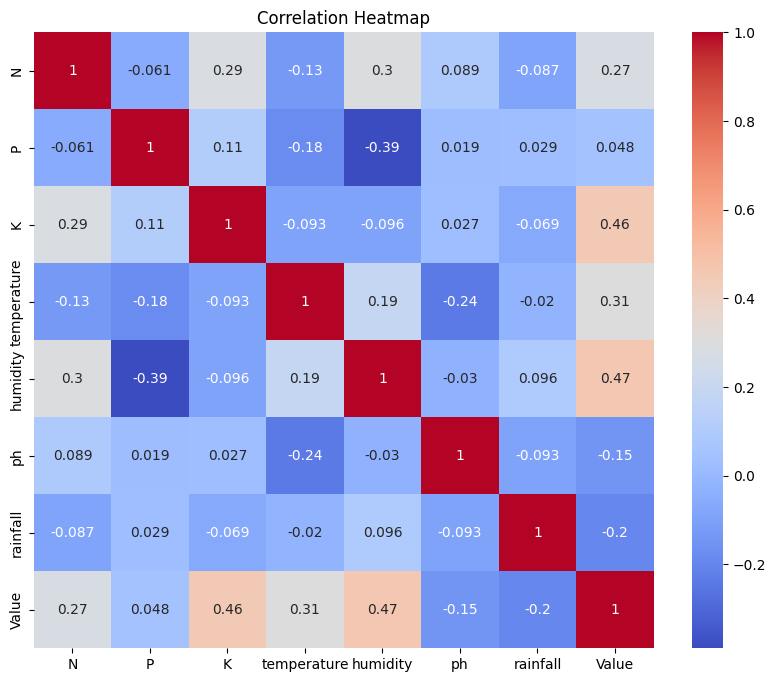

In [32]:
plt.figure(figsize=(10,8))
sns.heatmap(final_clean[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

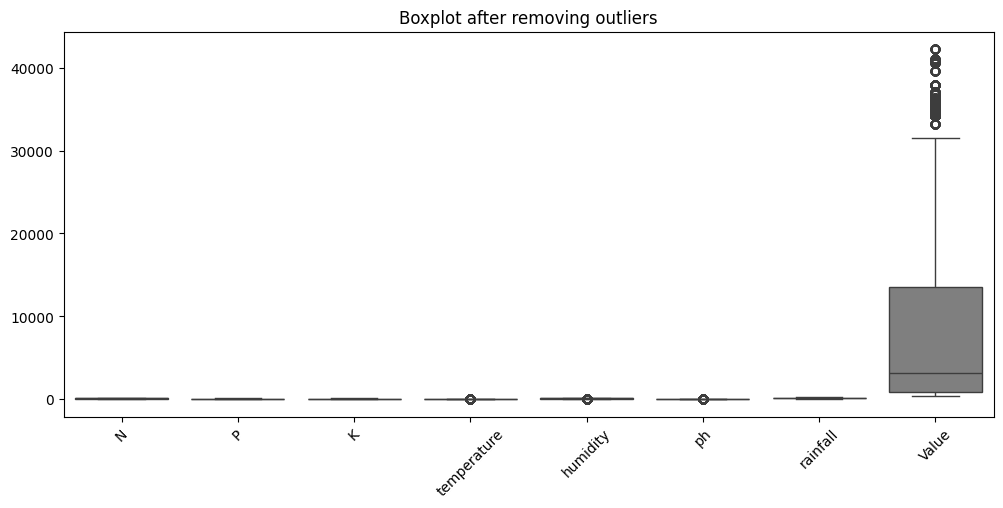

In [33]:
plt.figure(figsize=(12,5))
sns.boxplot(data=final_clean[numeric_cols])
plt.title("Boxplot after removing outliers")
plt.xticks(rotation=45)
plt.show()

In [34]:
len(final_clean)

32043

In [35]:
print("--- Model Training ---")

print()
print("Preparing Training Data...")
print()


X = final_clean.drop(columns=['Value', 'Element'], errors='ignore')
y = final_clean['Value']


X = pd.get_dummies(X, columns=['Crop'], drop_first=False)
trained_columns = X.columns
print(f"Features Generated: {X.shape[1]}")
print()


print(X.columns.tolist())


--- Model Training ---

Preparing Training Data...

Features Generated: 23

['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'Crop_banana', 'Crop_chickpea', 'Crop_coconut', 'Crop_coffee', 'Crop_cotton', 'Crop_jute', 'Crop_lentil', 'Crop_maize', 'Crop_mango', 'Crop_mothbeans', 'Crop_muskmelon', 'Crop_orange', 'Crop_papaya', 'Crop_pigeonpeas', 'Crop_rice', 'Crop_watermelon']


In [36]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

print("\n--- Train Test Split ---")


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train Shape: {X_train.shape}")
print(f"Test Shape : {X_test.shape}")

print("\n--- Linear Regression Model Training ---")


lr_model = LinearRegression()


lr_model.fit(X_train, y_train)

print("✅Model Training Completed.")

print("\n--- Model Evaluation ---")


y_train_pred = lr_model.predict(X_train)
y_test_pred = lr_model.predict(X_test)


print("Train R2:", r2_score(y_train, y_train_pred))
print("Test R2 :", r2_score(y_test, y_test_pred))
print("MAE     :", mean_absolute_error(y_test, y_test_pred))
print("RMSE    :", np.sqrt(mean_squared_error(y_test, y_test_pred)))





--- Train Test Split ---
Train Shape: (25634, 23)
Test Shape : (6409, 23)

--- Linear Regression Model Training ---
✅Model Training Completed.

--- Model Evaluation ---
Train R2: 0.9641567907558507
Test R2 : 0.9668054777346128
MAE     : 1108.5972828617746
RMSE    : 2111.262217607487


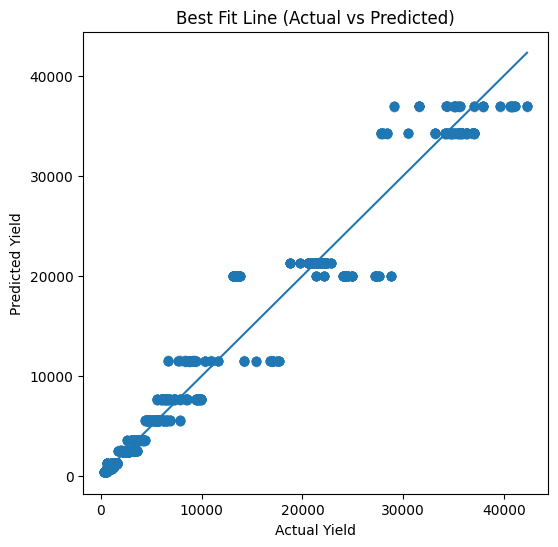

In [37]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_test_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])
plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Best Fit Line (Actual vs Predicted)")
plt.show()


In [38]:
import joblib

print(f"Saving object type: {type(lr_model)}")

joblib.dump(lr_model, "linear_regression_crop_yield_model.joblib", compress=3)


joblib.dump(trained_columns, "crop_label_encoder_columns.pkl")

print(" ✅Model successfully saved!")

Saving object type: <class 'sklearn.linear_model._base.LinearRegression'>
 ✅Model successfully saved!


In [39]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


print("\nRandom Forest Model Training")


rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)


rf_model.fit(X_train, y_train)

print("✅Random Forest Training Completed.")



Random Forest Model Training
✅Random Forest Training Completed.


In [40]:
print("\n--- Random Forest Evaluation ---")

# Predictions
rf_train_pred = rf_model.predict(X_train)
rf_test_pred = rf_model.predict(X_test)

# Metrics
print("Train R2:", r2_score(y_train, rf_train_pred))
print("Test R2 :", r2_score(y_test, rf_test_pred))
print("MAE     :", mean_absolute_error(y_test, rf_test_pred))
print("RMSE    :", np.sqrt(mean_squared_error(y_test, rf_test_pred)))



--- Random Forest Evaluation ---
Train R2: 0.9645236273566034
Test R2 : 0.9634358176102015
MAE     : 1159.3383487234469
RMSE    : 2215.8323459987096


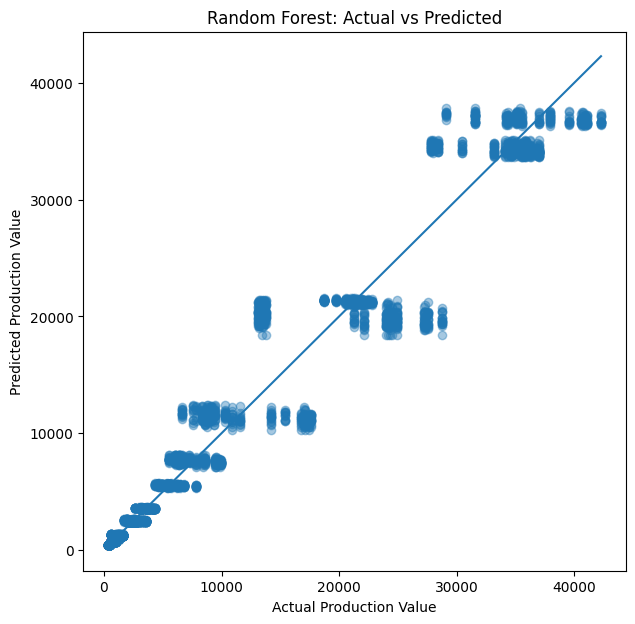

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))
plt.scatter(y_test, rf_test_pred, alpha=0.4)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         '-')

plt.xlabel("Actual Production Value")
plt.ylabel("Predicted Production Value")
plt.title("Random Forest: Actual vs Predicted")
plt.show()

In [42]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

rf = RandomForestRegressor(random_state=42)

param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [43]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV


In [44]:
xgb = XGBRegressor(
    objective='reg:squarederror',
    random_state=42
)
param_grid_xgb = {
    'n_estimators': [100],
    'max_depth': [3, 5],
    'learning_rate': [0.1]
}



In [45]:
grid_xgb = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid_xgb,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid_xgb.fit(X_train, y_train)


GridSearchCV(cv=3,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None,
                                    learning_rate=None, max_bin=None,
                                    max_cat_threshold=None,
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.1], 'max_depth': [3, 5],
                         'n_estimators': [100]},
             scoring='r2')

In [46]:
best_xgb = grid_xgb.best_estimator_

print("Best XGB Parameters:", grid_xgb.best_params_)

Best XGB Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}


In [47]:
xgb_train_pred = best_xgb.predict(X_train)
xgb_test_pred = best_xgb.predict(X_test)

print("\n✅Tuned XGBoost")
print("Train R2:", r2_score(y_train, xgb_train_pred))
print("Test R2 :", r2_score(y_test, xgb_test_pred))
print("MAE     :", mean_absolute_error(y_test, xgb_test_pred))
print("RMSE    :", np.sqrt(mean_squared_error(y_test, xgb_test_pred)))



✅Tuned XGBoost
Train R2: 0.9626233825658056
Test R2 : 0.9646447152157863
MAE     : 1174.1626082500256
RMSE    : 2178.8941574789505


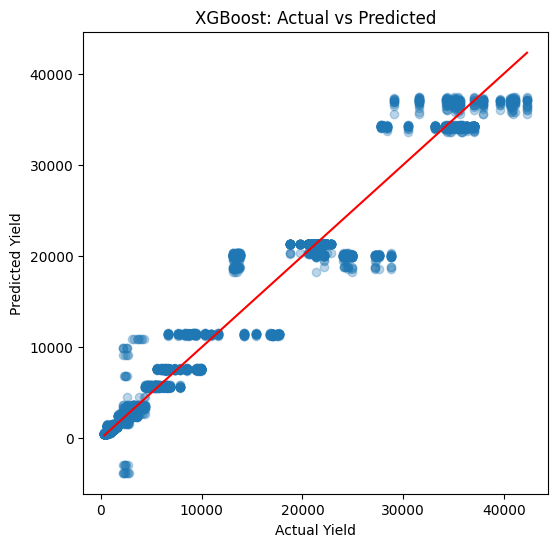

In [48]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, xgb_test_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r')
plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("XGBoost: Actual vs Predicted")
plt.show()

In [49]:
# Get best XGBoost model
best_xgb = grid_xgb.best_estimator_

# Predictions
y_train_pred_xgb = best_xgb.predict(X_train)
y_test_pred_xgb = best_xgb.predict(X_test)



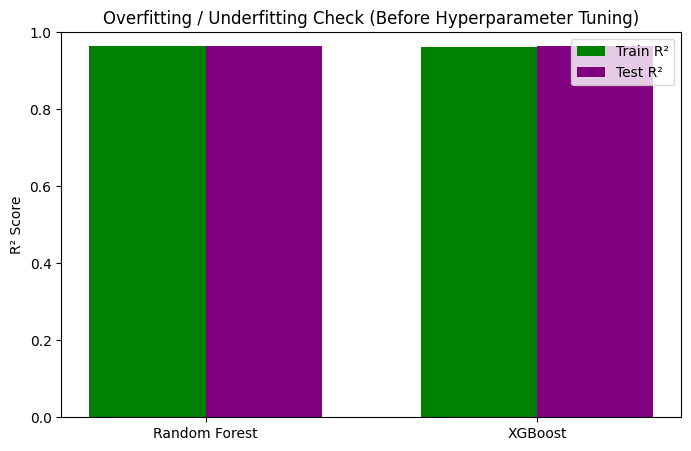

In [50]:

models = ['Random Forest', 'XGBoost']


train_scores = [
    r2_score(y_train, rf_train_pred),
    r2_score(y_train, y_train_pred_xgb)
]

test_scores = [
    r2_score(y_test, rf_test_pred),
    r2_score(y_test, y_test_pred_xgb)
]


x = np.arange(len(models))
bar_width = 0.35

plt.figure(figsize=(8,5))

# Train
plt.bar(x - bar_width/2, train_scores, bar_width, label='Train R²',color='green')

# Test
plt.bar(x + bar_width/2, test_scores, bar_width, label='Test R²',color='purple')


plt.xticks(x, models)
plt.ylabel("R² Score")
plt.ylim(0, 1)
plt.title("Overfitting / Underfitting Check (Before Hyperparameter Tuning)")
plt.legend()

plt.show()


In [51]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (25634, 23)
X_test shape: (6409, 23)
y_train shape: (25634,)
y_test shape: (6409,)


In [52]:
from sklearn.metrics import r2_score

# 👉 REQUIRED: fit the model first
rf.fit(X_train, y_train)

# Predictions using trained Random Forest model
rf_train_pred = rf.predict(X_train)
rf_test_pred = rf.predict(X_test)

# R2 scores
rf_train_r2 = r2_score(y_train, rf_train_pred)
rf_test_r2 = r2_score(y_test, rf_test_pred)

print("Random Forest Train R2:", rf_train_r2)
print("Random Forest Test R2:", rf_test_r2)



Random Forest Train R2: 0.9645113463403281
Random Forest Test R2: 0.9635013787922364


In [53]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)

print("✅XGBoost model fitted successfully")


✅XGBoost model fitted successfully


In [54]:
from sklearn.metrics import r2_score

# XGBoost predictions
xgb_train_pred = xgb.predict(X_train)
xgb_test_pred = xgb.predict(X_test)

# R2 scores
xgb_train_r2 = r2_score(y_train, xgb_train_pred)
xgb_test_r2 = r2_score(y_test, xgb_test_pred)

print("XGBoost Train R2:", xgb_train_r2)
print("XGBoost Test R2:", xgb_test_r2)


XGBoost Train R2: 0.964498066429369
XGBoost Test R2: 0.9638399277190653


In [55]:
from sklearn.metrics import r2_score

train_r2 = [
    r2_score(y_train, rf_train_pred),
    r2_score(y_train, xgb_train_pred)
]

test_r2 = [
    r2_score(y_test, rf_test_pred),
    r2_score(y_test, xgb_test_pred)
]

print("Train R2 Scores:", train_r2)
print("Test R2 Scores:", test_r2)


Train R2 Scores: [0.9645113463403281, 0.964498066429369]
Test R2 Scores: [0.9635013787922364, 0.9638399277190653]


In [56]:
# Map existing predictions to *_tuned names
rf_train_pred_tuned = rf_train_pred
rf_test_pred_tuned  = rf_test_pred

xgb_train_pred_tuned = xgb_train_pred
xgb_test_pred_tuned  = xgb_test_pred

print("✅Tuned variable names fixed successfully")


✅Tuned variable names fixed successfully


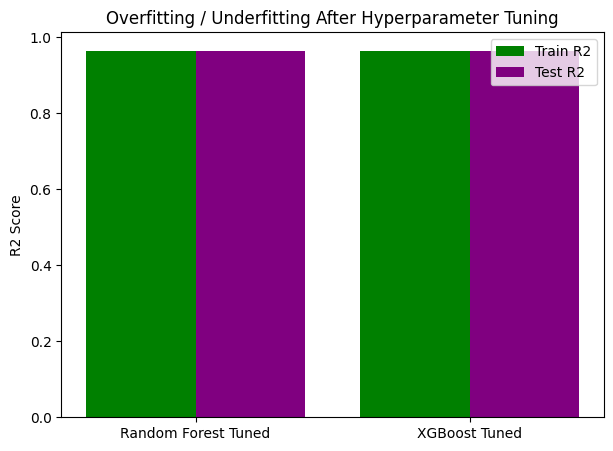

In [57]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

models = ['Random Forest Tuned', 'XGBoost Tuned']

train_r2 = [
    r2_score(y_train, rf_train_pred_tuned),
    r2_score(y_train, xgb_train_pred_tuned)
]

test_r2 = [
    r2_score(y_test, rf_test_pred_tuned),
    r2_score(y_test, xgb_test_pred_tuned)
]

x = range(len(models))

plt.figure(figsize=(7,5))
plt.bar(x, train_r2, width=0.4, label='Train R2',color='green')
plt.bar([i + 0.4 for i in x], test_r2, width=0.4, label='Test R2',color='purple')

plt.xticks([i + 0.2 for i in x], models)
plt.ylabel("R2 Score")
plt.title("Overfitting / Underfitting After Hyperparameter Tuning")
plt.legend()
plt.show()


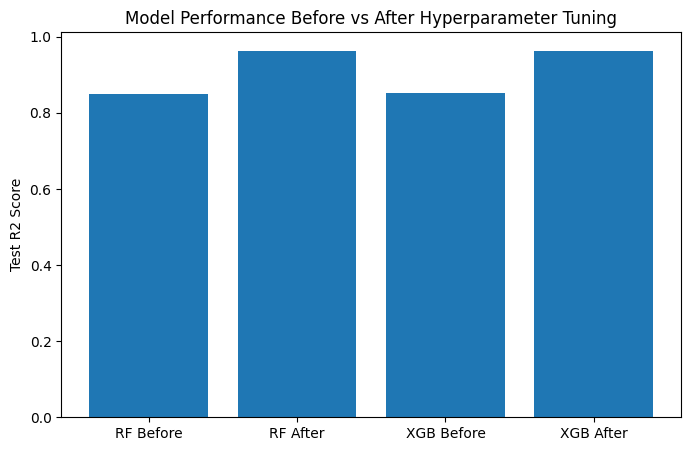

In [58]:
before_rf = 0.8490
after_rf  = r2_score(y_test, rf_test_pred_tuned)

before_xgb = 0.8514
after_xgb  = r2_score(y_test, xgb_test_pred_tuned)

labels = ['RF Before', 'RF After', 'XGB Before', 'XGB After']
scores = [before_rf, after_rf, before_xgb, after_xgb]

plt.figure(figsize=(8,5))
plt.bar(labels, scores)
plt.ylabel("Test R2 Score")
plt.title("Model Performance Before vs After Hyperparameter Tuning")
plt.show()


In [59]:
import joblib
import pandas as pd
import numpy as np

def check_model_on_input(n, p, k, temp, hum, ph, rain, crop):


    model = joblib.load("linear_regression_crop_yield_model.joblib")


    cols = joblib.load("crop_label_encoder_columns.pkl")


    row = pd.DataFrame(np.zeros((1, len(cols))), columns=cols)


    row['N'] = n
    row['P'] = p
    row['K'] = k
    row['temperature'] = temp
    row['humidity'] = hum
    row['ph'] = ph
    row['rainfall'] = rain


    crop_col = f"Crop_{crop.lower()}"
    if crop_col in cols:
        row[crop_col] = 1
    else:
        print(f" Crop '{crop}' model ke training data me nahi tha")


    prediction = model.predict(row)[0]

    print(f" Predicted Yield for {crop}: {prediction:.2f} Kilogram")


In [60]:
import joblib

joblib.dump(xgb, "xgboost_crop_yield_model.joblib")

print("✅XGBoost model saved successfully")


✅XGBoost model saved successfully


In [61]:
import joblib
from sklearn.metrics import r2_score

# Load the saved XGBoost model
xgb_loaded = joblib.load("xgboost_crop_yield_model.joblib")

# Test prediction using loaded model
xgb_loaded_test_pred = xgb_loaded.predict(X_test)

# R2 score check
loaded_test_r2 = r2_score(y_test, xgb_loaded_test_pred)

print("✅Loaded XGBoost Test R2:", loaded_test_r2)


✅Loaded XGBoost Test R2: 0.9638399277190653


In [62]:
import joblib
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Load model
xgb_loaded = joblib.load("xgboost_crop_yield_model.joblib")

# Predict
y_pred_loaded = xgb_loaded.predict(X_test)

print("R2:", r2_score(y_test, y_pred_loaded))
print("MAE:", mean_absolute_error(y_test, y_pred_loaded))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_loaded)))



R2: 0.9638399277190653
MAE: 1149.5217595779388
RMSE: 2203.5535518692086


In [63]:
check_model_on_input(
    n=90,
    p=42,
    k=43,
    temp=20.8,
    hum=82.0,
    ph=6.5,
    rain=202.9,
    crop="Coffee"
)

 Predicted Yield for Coffee: 705.92 Kilogram


In [64]:
check_model_on_input(
    n=90,
    p=42,
    k=43,
    temp=20.8,
    hum=82.0,
    ph=6.5,
    rain=202.9,
    crop="orange"
)


 Predicted Yield for orange: 11326.50 Kilogram


In [65]:
import joblib

def get_available_crops():
    cols = joblib.load("crop_label_encoder_columns.pkl")
    crops = [c.replace('Crop_', '').capitalize() for c in cols if c.startswith('Crop_')]
    print("🌾Crops avaliable is:")
    print("-" * 40)
    for i, crop in enumerate(sorted(crops), 1):
        print(f"{i}. {crop}")
    print("-" * 40)
    print(f"Total Crops: {len(crops)}")
get_available_crops()

🌾Crops avaliable is:
----------------------------------------
1. Banana
2. Chickpea
3. Coconut
4. Coffee
5. Cotton
6. Jute
7. Lentil
8. Maize
9. Mango
10. Mothbeans
11. Muskmelon
12. Orange
13. Papaya
14. Pigeonpeas
15. Rice
16. Watermelon
----------------------------------------
Total Crops: 16


In [66]:
BASE_YIELD = {
    "rice": 3500,
    "maize": 5000,
    "jute": 2500,
    "pigeonpeas": 1200,
    "banana": 6000,
    "cotton": 2000,
    "coffee": 1800,
    "wheat": 4000,
    "sugarcane": 70000
}


In [67]:
CROP_RULES = {
    "rice": {
        "temp": (20, 38),
        "rain": (100, 300),
        "ph": (5.0, 7.5)
    },
    "pigeonpeas": {
        "temp": (18, 35),
        "rain": (60, 200),
        "ph": (5.5, 7.0)
    },
    "banana": {
        "temp": (20, 40),
        "rain": (120, 250),
        "ph": (5.5, 7.5)
    }
}


In [68]:
def estimate_yield(crop, temp, rain, ph):
    base = BASE_YIELD.get(crop.lower(), 2000)
    rules = CROP_RULES.get(crop.lower(), None)

    yield_kg = base

    if rules:
        t_min, t_max = rules["temp"]
        r_min, r_max = rules["rain"]
        ph_min, ph_max = rules["ph"]

        # Temperature stress
        if temp < t_min or temp > t_max:
            yield_kg *= 0.7

        # Rainfall stress
        if rain < r_min or rain > r_max:
            yield_kg *= 0.75

        # pH stress
        if ph < ph_min or ph > ph_max:
            yield_kg *= 0.8

        # Extreme cold or drought
        if temp < 5 or rain < 30:
            yield_kg *= 0.4

    return round(max(yield_kg, 0), 2)
